# Задание III. Кластеризация — вариант 4

| Пункт | Метод по варианту |
|---|---|
| 2 — пропуски | `KNNImputer(n_neighbors=5)` |
| 3 — шкалы | `MaxAbsScaler` + `OneHotEncoder` |
| 4 — иерархическая кластеризация | `link=average`, `dist=euclidean` |
| 6 — проекция | PCA |
| 7 — кластеры с прототипом | KMeans |
| 10 — VarClus | 5 переменных |

Структура: для пунктов 3–7 пишутся небольшие функции и вызываются по шагам;
в пункте 8 они собираются в одну функцию `cluster_analysis`, которая затем
перезапускается в пунктах 9 и 10.

In [ ]:
%pip install -q varclushi

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist
from varclushi import VarClusHi

pd.set_option('display.max_colwidth', None)

SEED = 42
# Палитра кластеров (фиксированный порядок) + маркеры как второе кодирование,
# чтобы кластеры различались не только цветом
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
TEXT, MUTED = '#0b0b0b', '#8a8984'
set_link_color_palette(COLORS)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#e5e4e0', 'grid.linewidth': 0.6,
    'axes.edgecolor': MUTED, 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'axes.titlecolor': TEXT,
})

## 1. Загрузка данных

`Name` — идентификатор записи (роль ID), он становится индексом.
Остальные переменные — входы (INPUT): 18 интервальных и 5 номинальных.

In [3]:
df = pd.read_csv('baseball.csv').set_index('Name')

CAT = ['Team', 'Position', 'League', 'Division', 'Div']           # NOMINAL
NUM = [c for c in df.columns if c not in CAT]                      # INTERVAL
print(f'Наблюдений: {len(df)}, имена уникальны: {df.index.is_unique}')
print(f'Интервальные ({len(NUM)}): {NUM}')
print(f'Номинальные ({len(CAT)}): {CAT}')
df.head()

Наблюдений: 322, имена уникальны: True
Интервальные (18): ['nAtBat', 'nHits', 'nHome', 'nRuns', 'nRBI', 'nBB', 'YrMajor', 'CrAtBat', 'CrHits', 'CrHome', 'CrRuns', 'CrRbi', 'CrBB', 'nOuts', 'nAssts', 'nError', 'Salary', 'logSalary']
Номинальные (5): ['Team', 'Position', 'League', 'Division', 'Div']


,Team,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,...,CrBB,League,Division,Position,nOuts,nAssts,nError,Salary,Div,logSalary
Name,,,,,,,,,,,,,,,,,,,,,
"Allanson, Andy",Cleveland,293,66,1,30,29,14,1,293,66,...,14,American,East,C,446,33,20,NaN,AE,NaN
"Ashby, Alan",Houston,315,81,7,24,38,39,14,3449,835,...,375,National,West,C,632,43,10,475.0,NW,6.163315
"Davis, Alan",Seattle,479,130,18,66,72,76,3,1624,457,...,263,American,West,1B,880,82,14,480.0,AW,6.173786
"Dawson, Andre",Montreal,496,141,20,65,78,37,11,5628,1575,...,354,National,East,RF,200,11,3,500.0,NE,6.214608
"Galarraga, Andres",Montreal,321,87,10,39,42,30,2,396,101,...,33,National,East,1B,805,40,4,91.5,NE,4.516339


In [4]:
pd.DataFrame({
    'тип': df.dtypes.astype(str),
    'пропусков': df.isna().sum(),
    'уникальных': df.nunique(),
}).T

,Team,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,...,CrBB,League,Division,Position,nOuts,nAssts,nError,Salary,Div,logSalary
тип,str,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,int64,str,str,str,int64,int64,int64,float64,str,float64
пропусков,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,59,0,59
уникальных,24,246,136,37,91,100,85,22,315,287,...,248,2,2,25,234,161,29,150,4,150


## 2. Обработка пропусков: `KNNImputer(n_neighbors=5)`

Пропуски есть только в `Salary` и `logSalary` (одни и те же игроки).
Зарплата игрока подставляется как среднее по 5 ближайшим по статистике игрокам.

KNN опирается на расстояния, поэтому на исходных шкалах карьерные показатели
(`CrAtBat` ~ 14 000) полностью задавили бы сезонные (`nHome` ~ 40). Поэтому
расстояния для импутации считаются в шкале `MaxAbsScaler`, после чего значения
возвращаются в исходные единицы. `logSalary` в импутацию не подаётся — это функция
от `Salary`; после подстановки она пересчитывается как `log(1 + Salary)`.

In [5]:
num_base = [c for c in NUM if c != 'logSalary']
missing = df['Salary'].isna()
print(f'Пропусков в Salary: {missing.sum()} из {len(df)} ({missing.mean():.0%})')

tmp_scaler = MaxAbsScaler()                       # NaN игнорируются при fit
imputed = KNNImputer(n_neighbors=5).fit_transform(tmp_scaler.fit_transform(df[num_base]))

df_imp = df.copy()
df_imp[num_base] = tmp_scaler.inverse_transform(imputed)
df_imp['logSalary'] = np.log1p(df_imp['Salary'])
assert df_imp[NUM].notna().all().all()

df_imp.loc[missing, ['YrMajor', 'nHits', 'CrHits', 'Salary', 'logSalary']].head(8).round(2)

Пропусков в Salary: 59 из 322 (18%)


,YrMajor,nHits,CrHits,Salary,logSalary
Name,,,,,
"Allanson, Andy",1.0,66.0,66.0,101.40,4.63
"Beane, Billy",3.0,39.0,42.0,122.93,4.82
"Bochte, Bruce",12.0,104.0,1478.0,784.00,6.67
"Boone, Bob",15.0,98.0,1501.0,659.00,6.49
"Grich, Bobby",17.0,84.0,1833.0,550.67,6.31
"Horner, Bob",9.0,141.0,994.0,1105.45,7.01
"Meacham, Bobby",4.0,36.0,244.0,215.00,5.38
"Oglivie, Ben",16.0,98.0,1615.0,635.00,6.46


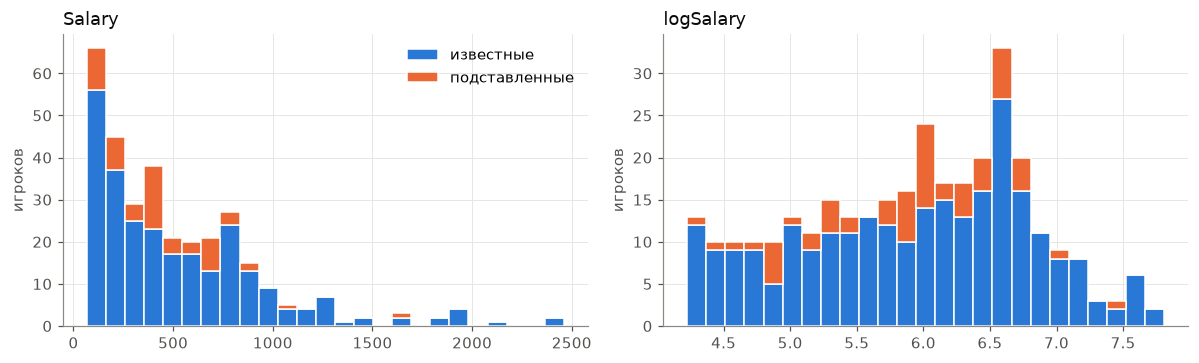

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col in zip(axes, ['Salary', 'logSalary']):
    ax.hist([df_imp.loc[~missing, col], df_imp.loc[missing, col]], bins=25, stacked=True,
            color=COLORS[:2], edgecolor='white', label=['известные', 'подставленные'])
    ax.set_title(col, loc='left')
    ax.set_ylabel('игроков')
axes[0].legend(frameon=False)
plt.tight_layout()

Подставленные зарплаты лежат внутри наблюдаемого распределения (не прижаты к
одному значению, как было бы при подстановке среднего). Логарифм `log(1+x)`
делает распределение почти симметричным: асимметрия Salary и logSalary:

In [7]:
df_imp[['Salary', 'logSalary']].skew().round(2)

Salary       1.67
logSalary   -0.18
dtype: float64

## 3. Нормализация: `MaxAbsScaler` + `OneHotEncoder`

`MaxAbsScaler` делит каждый признак на его максимум по модулю. Все числовые
признаки здесь неотрицательны, поэтому шкала становится [0, 1] — та же, что у
бинарных колонок `OneHotEncoder`.

In [8]:
def prepare(data, num_cols, cat_cols):
    """п.3: числовые -> MaxAbsScaler, номинальные -> OneHotEncoder."""
    parts = [pd.DataFrame(MaxAbsScaler().fit_transform(data[num_cols]),
                          index=data.index, columns=num_cols)]
    if cat_cols:
        ohe = OneHotEncoder(sparse_output=False)
        parts.append(pd.DataFrame(ohe.fit_transform(data[cat_cols]), index=data.index,
                                  columns=ohe.get_feature_names_out(cat_cols)))
    return pd.concat(parts, axis=1)

X = prepare(df_imp, NUM, CAT)
print(f'Матрица признаков: {X.shape[0]} x {X.shape[1]} '
      f'(числовых {len(NUM)}, бинарных {X.shape[1] - len(NUM)})')
X.describe().T[['min', 'max', 'mean']].round(2).T

Матрица признаков: 322 x 75 (числовых 18, бинарных 57)


,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,CrHome,...,Position_SS,Position_UT,League_American,League_National,Division_East,Division_West,Div_AE,Div_AW,Div_NE,Div_NW
min,0.18,0.13,0.00,0.09,0.07,0.03,0.04,0.01,0.01,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
mean,0.57,0.43,0.28,0.40,0.41,0.38,0.32,0.20,0.18,0.14,...,0.09,0.04,0.54,0.46,0.49,0.51,0.26,0.28,0.22,0.23


## 4. Восходящая иерархическая кластеризация (average, euclidean)

Расстояние между кластерами — среднее евклидово расстояние между всеми парами
их объектов. Дендрограмма показана для верхних 20 кластеров
(`truncate_mode='lastp'`); в скобках — число игроков в свёрнутой ветви.

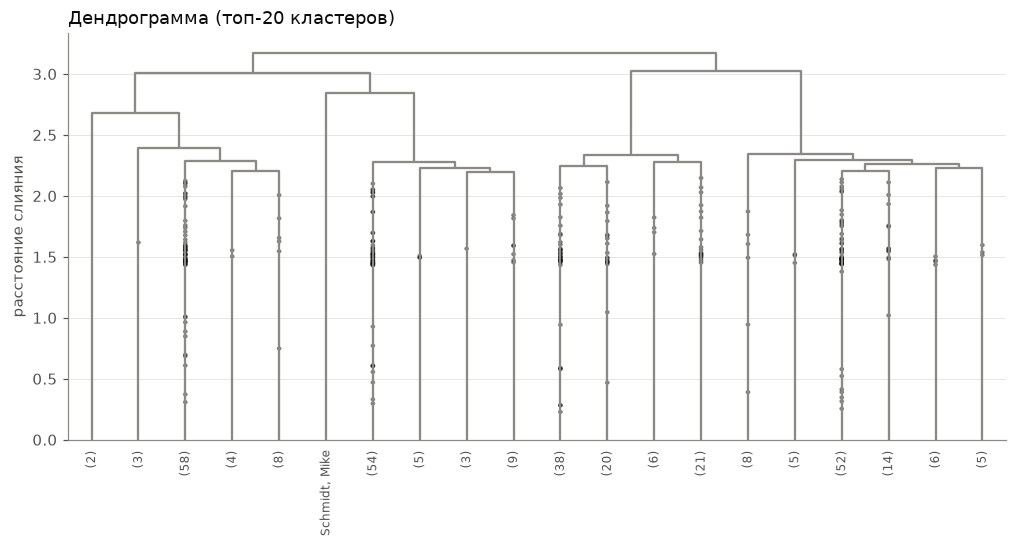

In [9]:
def hier_cluster(X):
    """п.4: матрица слияний восходящей кластеризации."""
    return linkage(X, method='average', metric='euclidean')

def plot_dendrogram(Z, ax, labels, k=None, title='Дендрограмма (топ-20 кластеров)'):
    """Если задано k — ветви k кластеров раскрашиваются. Листья: (n) — число
    игроков в свёрнутой ветви, имя — одиночный игрок."""
    thr = (Z[-k, 2] + Z[-(k - 1), 2]) / 2 if k else 0
    dendrogram(Z, truncate_mode='lastp', p=20, show_contracted=True, ax=ax, labels=list(labels),
               color_threshold=thr, above_threshold_color=MUTED, leaf_font_size=8, leaf_rotation=90)
    if k:
        ax.axhline(thr, color=TEXT, lw=0.8, ls='--')
        ax.text(ax.get_xlim()[1], thr, f'  разрез на k={k}', va='bottom', ha='right', color=TEXT)
    ax.set_title(title, loc='left')
    ax.set_ylabel('расстояние слияния')
    ax.grid(axis='x', visible=False)

Z = hier_cluster(X)
fig, ax = plt.subplots(figsize=(11, 4.8))
plot_dendrogram(Z, ax, X.index)

## 5. Критерий pseudoF и выбор числа кластеров

pseudoF (псевдо-Фишер, статистика Калински–Харабаша) сравнивает межкластерный и
внутрикластерный разброс с поправкой на число степеней свободы:

$$pseudoF(k) = \frac{B/(k-1)}{W/(n-k)}, \quad
W = \sum_{c=1}^{k}\sum_{x_i \in c}\|x_i - \bar x_c\|^2, \quad
B = \sum_{i=1}^{n}\|x_i - \bar x\|^2 - W$$

Чем больше — тем компактнее кластеры относительно расстояний между ними.
Для каждого k = 2..20 дерево из п.4 разрезается на k кластеров (`fcluster`),
оптимальное k — **первый локальный пик** при обходе от малых k к большим.

Оптимальное число кластеров: 4


,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
pseudoF,72.1,75.3,82.3,62.6,51.3,43.5,38.7,35.7,32.6,30.3,28.5,26.7,25.4,24.6,23.4,22.3,21.4,20.6,19.7


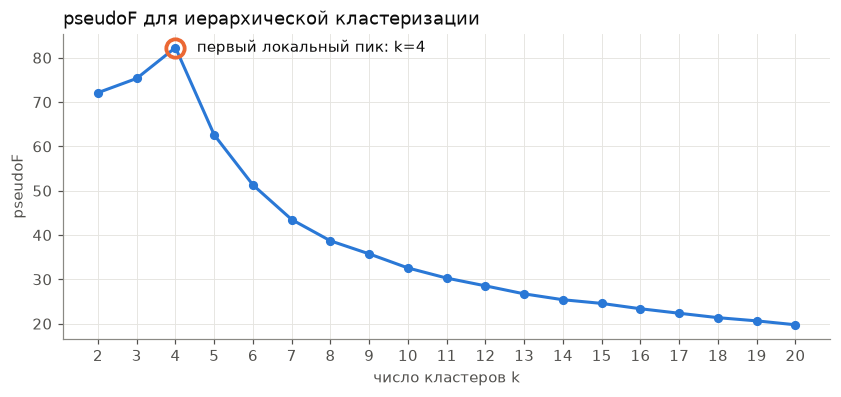

In [10]:
def pseudo_f(X, labels):
    """pseudoF по формуле выше."""
    X = np.asarray(X)
    n, k = len(X), len(np.unique(labels))
    W = sum(((X[labels == c] - X[labels == c].mean(axis=0)) ** 2).sum() for c in np.unique(labels))
    B = ((X - X.mean(axis=0)) ** 2).sum() - W
    return (B / (k - 1)) / (W / (n - k))

def pseudo_f_curve(X, Z, k_range=range(2, 21)):
    return pd.Series({k: pseudo_f(X, fcluster(Z, k, criterion='maxclust')) for k in k_range})

def first_local_peak(f):
    """Первое k, где pseudoF больше соседей (k=2 сравнивается только с k=3)."""
    v = f.values
    for i in range(len(v) - 1):
        if v[i] > v[i + 1] and (i == 0 or v[i] > v[i - 1]):
            return int(f.index[i])
    return int(f.idxmax())

def plot_pseudo_f(f, k_opt, ax):
    ax.plot(f.index, f.values, color=COLORS[0], lw=2, marker='o', ms=5)
    ax.plot(k_opt, f[k_opt], marker='o', ms=12, mfc='none', mec=COLORS[1], mew=2.5)
    ax.annotate(f'первый локальный пик: k={k_opt}', (k_opt, f[k_opt]),
                xytext=(14, 0), textcoords='offset points', va='center', color=TEXT)
    ax.set_xticks(list(f.index))
    ax.set_xlabel('число кластеров k')
    ax.set_ylabel('pseudoF')
    ax.set_title('pseudoF для иерархической кластеризации', loc='left')

labels_check = fcluster(Z, 4, criterion='maxclust')
assert np.isclose(pseudo_f(X, labels_check), calinski_harabasz_score(X, labels_check))  # формула = sklearn

f = pseudo_f_curve(X, Z)
k_opt = first_local_peak(f)
fig, ax = plt.subplots(figsize=(9, 3.6))
plot_pseudo_f(f, k_opt, ax)
print(f'Оптимальное число кластеров: {k_opt}')
f.round(1).to_frame('pseudoF').T

Размеры кластеров: {np.int32(1): np.int64(75), np.int32(2): np.int64(72), np.int32(3): np.int64(85), np.int32(4): np.int64(90)}


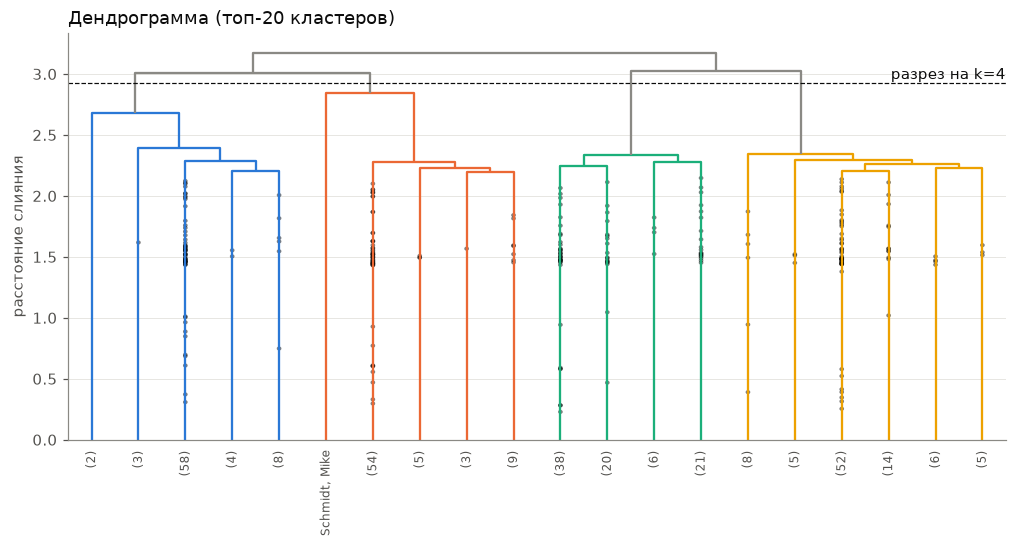

In [11]:
hier_labels = fcluster(Z, k_opt, criterion='maxclust')
print('Размеры кластеров:', dict(zip(*np.unique(hier_labels, return_counts=True))))
fig, ax = plt.subplots(figsize=(11, 4.8))
plot_dendrogram(Z, ax, X.index, k=k_opt)

## 6. Проекция на плоскость: PCA

Наблюдения проецируются на первые две главные компоненты матрицы признаков из
п.3; цвет и форма точки — номер кластера иерархической кластеризации при
оптимальном k.

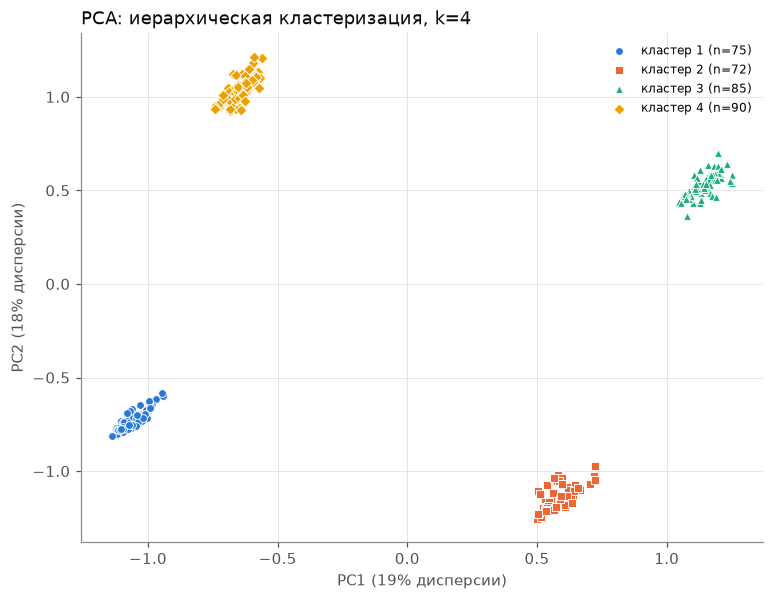

In [12]:
def scatter_clusters(P, labels, ax, title):
    for i, c in enumerate(np.unique(labels)):
        m = labels == c
        ax.scatter(P[m, 0], P[m, 1], s=26, color=COLORS[i % 8], marker=MARKERS[i % 8],
                   edgecolor='white', linewidth=0.6, label=f'кластер {c} (n={m.sum()})')
    ax.legend(frameon=False, fontsize=8, loc='best')
    ax.set_title(title, loc='left')

def pca_projection(X):
    """п.6: PCA(2); возвращает модель и координаты."""
    pca = PCA(n_components=2, random_state=SEED)
    return pca, pca.fit_transform(X)

def label_axes(ax, pca):
    r = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({r[0]:.0%} дисперсии)')
    ax.set_ylabel(f'PC2 ({r[1]:.0%} дисперсии)')

pca, P = pca_projection(X)
fig, ax = plt.subplots(figsize=(8, 6))
scatter_clusters(P, hier_labels, ax, f'PCA: иерархическая кластеризация, k={k_opt}')
label_axes(ax, pca)

In [13]:
# Какие признаки формируют главные компоненты (топ-8 по модулю веса)
load = pd.DataFrame(pca.components_.T, index=X.columns, columns=['PC1', 'PC2'])
top = lambda pc: load[pc].reindex(load[pc].abs().sort_values(ascending=False).index[:8])
pd.concat({pc: top(pc).rename_axis('признак').reset_index(name='вес') for pc in ['PC1', 'PC2']},
          axis=1).round(3)

PC1                     PC2       
           признак    вес          признак    вес
0    Division_East  0.539  League_American  0.539
1    Division_West -0.539  League_National -0.539
2           Div_AE  0.376           Div_AW  0.365
3           Div_NW -0.310           Div_NE -0.325
4           Div_AW -0.229           Div_NW -0.214
5           Div_NE  0.163           Div_AE  0.174
6  League_American  0.147    Division_East -0.151
7  League_National -0.147    Division_West  0.151

## 7. Сферические кластеры с прототипом: KMeans

KMeans с тем же числом кластеров k. Прототип кластера — центроид; **наиболее
типичный представитель** — игрок, ближайший к центроиду (евклидово расстояние в
пространстве признаков п.3). Центроиды и типичные игроки отмечены на проекции
из п.6. Номера кластеров KMeans согласованы с иерархическими (по максимальному
совпадению состава), чтобы один цвет означал «тот же» кластер. Для интерпретации — средние значения ключевых показателей в исходных единицах.

In [14]:
PROFILE = ['YrMajor', 'nHits', 'nHome', 'nRuns', 'CrHits', 'nOuts', 'nAssts', 'Salary']

def match_labels(labels, ref):
    """Перенумеровать кластеры labels так, чтобы они максимально совпадали с ref."""
    ct = pd.crosstab(labels, ref)
    rows, cols = linear_sum_assignment(-ct.values)
    mapping = dict(zip(ct.index[rows], ct.columns[cols]))
    return np.array([mapping[l] for l in labels])

def kmeans_typical(X, k, profile, ref=None):
    """п.7: KMeans + ближайший к центроиду игрок в каждом кластере."""
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    labels = km.labels_ + 1 if ref is None else match_labels(km.labels_, ref)
    own = km.transform(X)[np.arange(len(X)), km.labels_]   # расстояние до своего центроида
    rows = []
    for c in np.unique(labels):
        m = labels == c
        idx = np.argmin(np.where(m, own, np.inf))
        rows.append({'кластер': c, 'игроков': m.sum(), 'типичный игрок': X.index[idx],
                     'до центроида': own[idx], **profile[m].mean().round(1).to_dict()})
    return km, labels, pd.DataFrame(rows).set_index('кластер')

km, km_labels, typical = kmeans_typical(X, k_opt, df_imp[PROFILE], ref=hier_labels)
typical

,игроков,типичный игрок,до центроида,YrMajor,nHits,nHome,nRuns,CrHits,nOuts,nAssts,Salary
кластер,,,,,,,,,,,
1,75,"Landreaux, Ken",1.355776,8.1,96.8,9.5,46.4,818.8,298.1,111.2,475.1
2,72,"Wilson, Mookie",1.329003,6.5,99.8,9.4,49.7,617.4,294.4,116.3,529.9
3,85,"Hassey, Ron",1.358816,8.4,113.3,13.0,58.5,836.3,287.4,102.6,629.0
4,90,"Henderson, Dave",1.370972,7.5,102.4,12.0,53.2,708.9,278.6,100.0,442.9


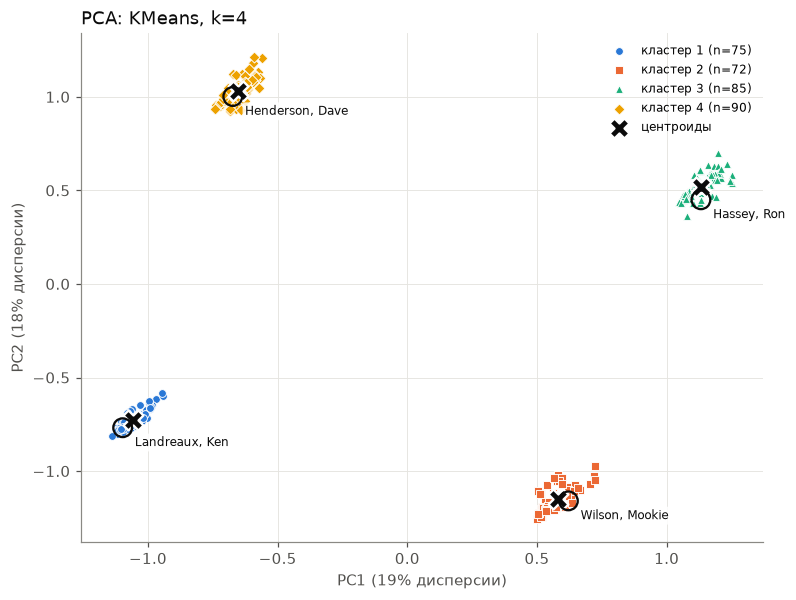

In [15]:
def plot_kmeans(P, index, labels, km, pca, typical, ax):
    scatter_clusters(P, labels, ax, f'PCA: KMeans, k={km.n_clusters}')
    C = pca.transform(pd.DataFrame(km.cluster_centers_, columns=pca.feature_names_in_))
    ax.scatter(C[:, 0], C[:, 1], marker='X', s=170, color=TEXT, edgecolor='white',
               linewidth=1.5, zorder=5, label='центроиды')
    for name in typical['типичный игрок']:
        x, y = P[index.get_loc(name)]
        ax.scatter(x, y, s=150, facecolor='none', edgecolor=TEXT, linewidth=1.5, zorder=6)
        ax.annotate(name, (x, y), xytext=(8, -12), textcoords='offset points', fontsize=8,
                    color=TEXT, zorder=7, bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))
    ax.legend(frameon=False, fontsize=8, loc='best')

fig, ax = plt.subplots(figsize=(8, 6))
plot_kmeans(P, X.index, km_labels, km, pca, typical, ax)
label_axes(ax, pca)

In [16]:
# Насколько совпадают разбиения иерархии и KMeans
pd.crosstab(pd.Series(hier_labels, name='иерархия'), pd.Series(km_labels, name='KMeans'))

KMeans,1,2,3,4
иерархия,,,,
1,75,0,0,0
2,0,72,0,0
3,0,0,85,0
4,0,0,0,90


## 8. Шаги 3–7 в виде функции

`cluster_analysis` собирает функции из пунктов 3–7: подготовка признаков →
иерархическая кластеризация → pseudoF и выбор k → PCA → KMeans с типичными
представителями. Рисует 4 графика и возвращает результаты. Проверка: на
исходных данных функция воспроизводит результат пунктов 3–7.

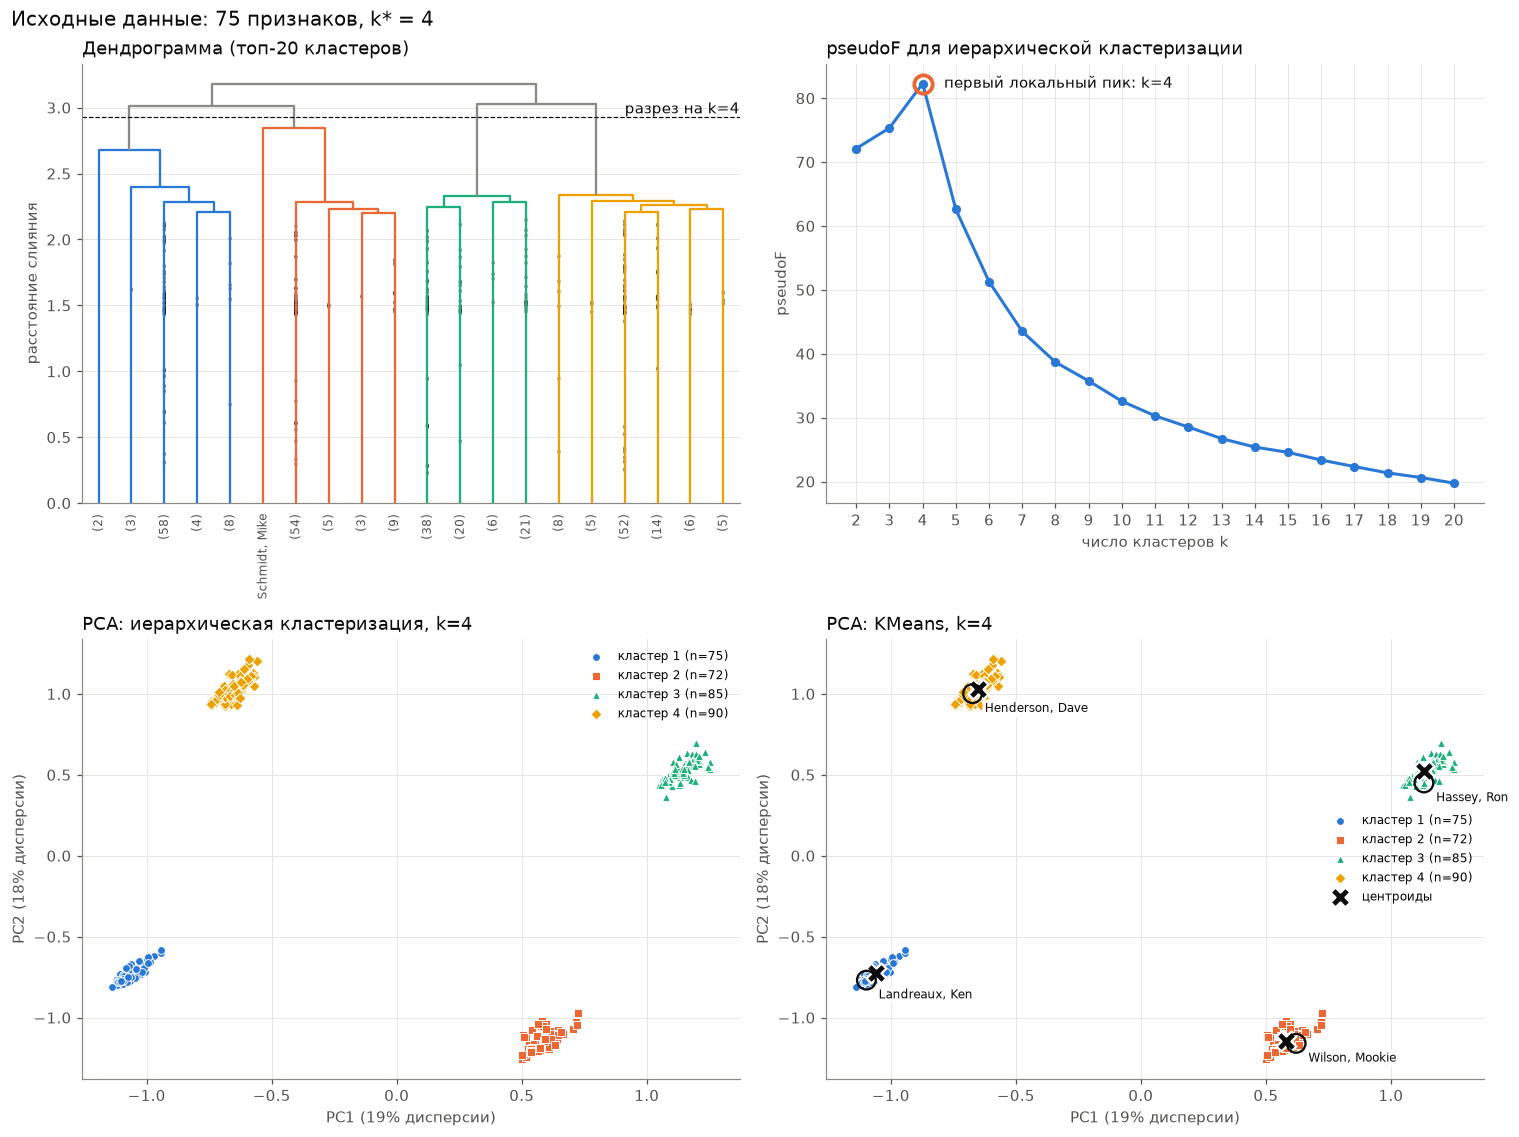

,игроков,типичный игрок,до центроида,YrMajor,nHits,nHome,nRuns,CrHits,nOuts,nAssts,Salary
кластер,,,,,,,,,,,
1,75,"Landreaux, Ken",1.355776,8.1,96.8,9.5,46.4,818.8,298.1,111.2,475.1
2,72,"Wilson, Mookie",1.329003,6.5,99.8,9.4,49.7,617.4,294.4,116.3,529.9
3,85,"Hassey, Ron",1.358816,8.4,113.3,13.0,58.5,836.3,287.4,102.6,629.0
4,90,"Henderson, Dave",1.370972,7.5,102.4,12.0,53.2,708.9,278.6,100.0,442.9


In [17]:
def cluster_analysis(data, num_cols, cat_cols, title, profile=None):
    """Шаги 3-7 для набора data. profile — данные в исходных единицах для
    описания кластеров (по умолчанию data)."""
    profile = data if profile is None else profile
    X = prepare(data, num_cols, cat_cols)                                    # п.3
    Z = hier_cluster(X)                                                      # п.4
    f = pseudo_f_curve(X, Z)                                                 # п.5
    k = first_local_peak(f)
    hier_labels = fcluster(Z, k, criterion='maxclust')
    pca, P = pca_projection(X)                                               # п.6
    km, km_labels, typical = kmeans_typical(X, k, profile[PROFILE], ref=hier_labels)  # п.7

    fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))
    plot_dendrogram(Z, axes[0, 0], X.index, k=k)
    plot_pseudo_f(f, k, axes[0, 1])
    scatter_clusters(P, hier_labels, axes[1, 0], f'PCA: иерархическая кластеризация, k={k}')
    plot_kmeans(P, X.index, km_labels, km, pca, typical, axes[1, 1])
    for ax in axes[1]:
        label_axes(ax, pca)
    fig.suptitle(f'{title}: {X.shape[1]} признаков, k* = {k}', x=0.01, ha='left',
                 fontsize=13, color=TEXT)
    plt.tight_layout()
    plt.show()
    return dict(title=title, n_features=X.shape[1], X=X, pseudo_f=f, k=k,
                hier_labels=hier_labels, km_labels=km_labels, typical=typical)

res_base = cluster_analysis(df_imp, NUM, CAT, 'Исходные данные')
assert res_base['k'] == k_opt and (res_base['km_labels'] == km_labels).all()
res_base['typical']

## 9. Симметризация распределений: `log(1+x)`

Ищем переменные с одной модой и тяжёлым правым хвостом: асимметрия
(`skew`) > 1 и гистограмма с одним пиком у левого края. Для них применяется
`log(1+x)` (`+1` — потому что у части переменных есть нули).

Логарифмируем: ['CrHome', 'nOuts', 'CrBB', 'Salary', 'CrRbi', 'nAssts', 'CrRuns', 'CrHits', 'CrAtBat', 'nError']


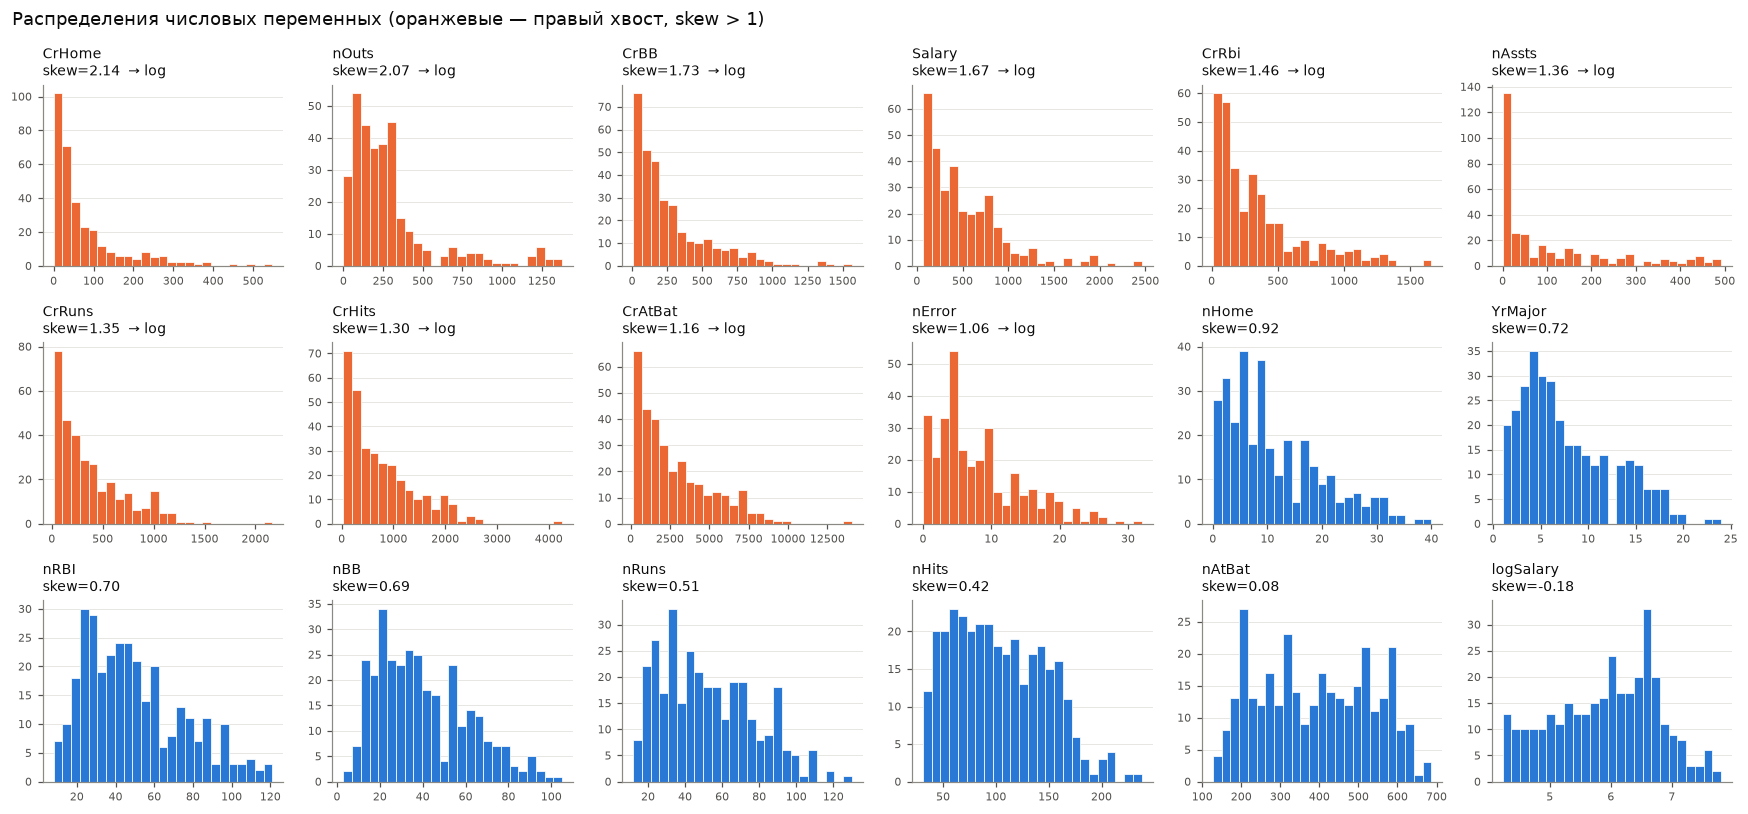

In [18]:
skew = df_imp[NUM].skew().sort_values(ascending=False)
RIGHT = skew[skew > 1].index.tolist()

fig, axes = plt.subplots(3, 6, figsize=(16, 7.5))
for ax, col in zip(axes.flat, skew.index):
    sel = col in RIGHT
    ax.hist(df_imp[col], bins=25, color=COLORS[1] if sel else COLORS[0], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col}\nskew={skew[col]:.2f}' + ('  → log' if sel else ''), loc='left', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(axis='x', visible=False)
fig.suptitle('Распределения числовых переменных (оранжевые — правый хвост, skew > 1)',
             x=0.01, ha='left', fontsize=12, color=TEXT)
plt.tight_layout()
print('Логарифмируем:', RIGHT)

In [19]:
df_log = df_imp.copy()
df_log[RIGHT] = np.log1p(df_log[RIGHT])
pd.DataFrame({'skew до': df_imp[RIGHT].skew(), 'skew после': df_log[RIGHT].skew()}).round(2).T

,CrHome,nOuts,CrBB,Salary,CrRbi,nAssts,CrRuns,CrHits,CrAtBat,nError
skew до,2.14,2.07,1.73,1.67,1.46,1.36,1.35,1.30,1.16,1.06
skew после,-0.41,-2.20,-0.32,-0.18,-0.37,-0.23,-0.39,-0.42,-0.42,-0.60


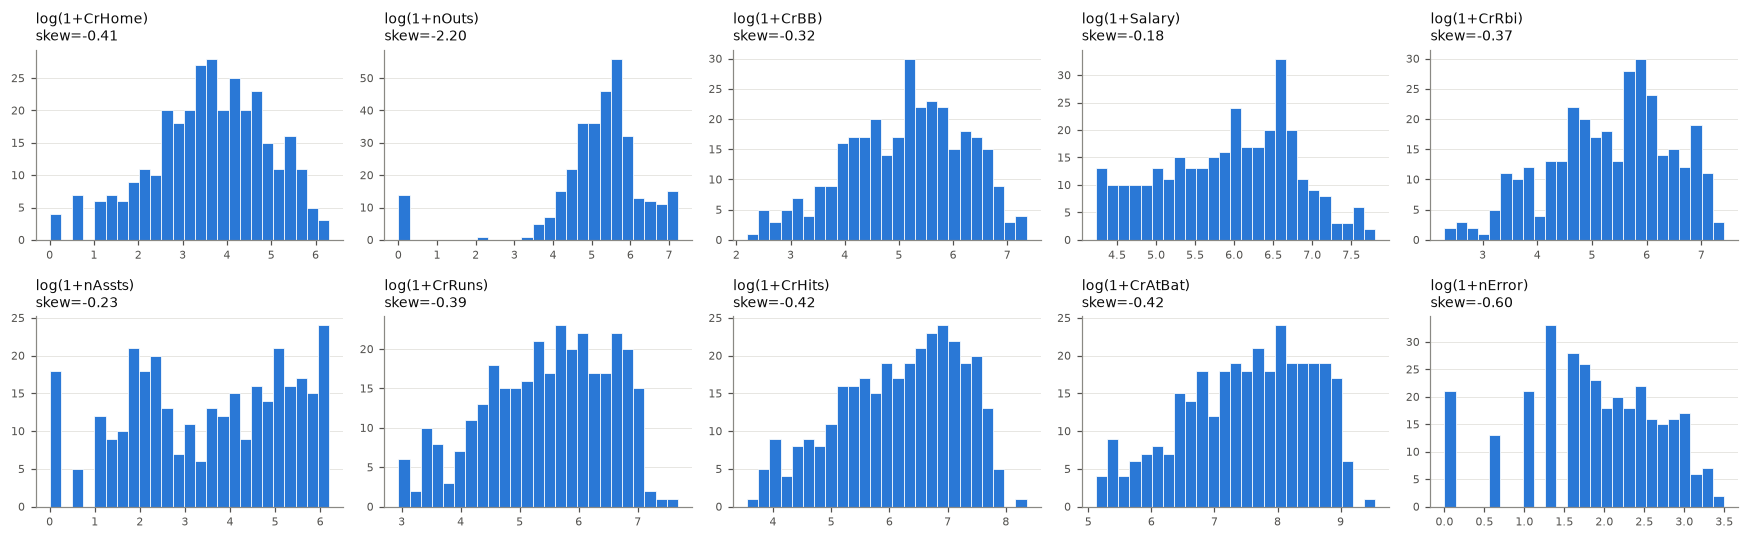

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(16, 5))
for ax, col in zip(axes.flat, RIGHT):
    ax.hist(df_log[col], bins=25, color=COLORS[0], edgecolor='white', linewidth=0.5)
    ax.set_title(f'log(1+{col})\nskew={df_log[col].skew():.2f}', loc='left', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(axis='x', visible=False)
plt.tight_layout()

`Salary` после `log(1+x)` совпадает с `logSalary` (её мы так и пересчитали в п.2),
поэтому дальше зарплата фактически входит в данные дважды.

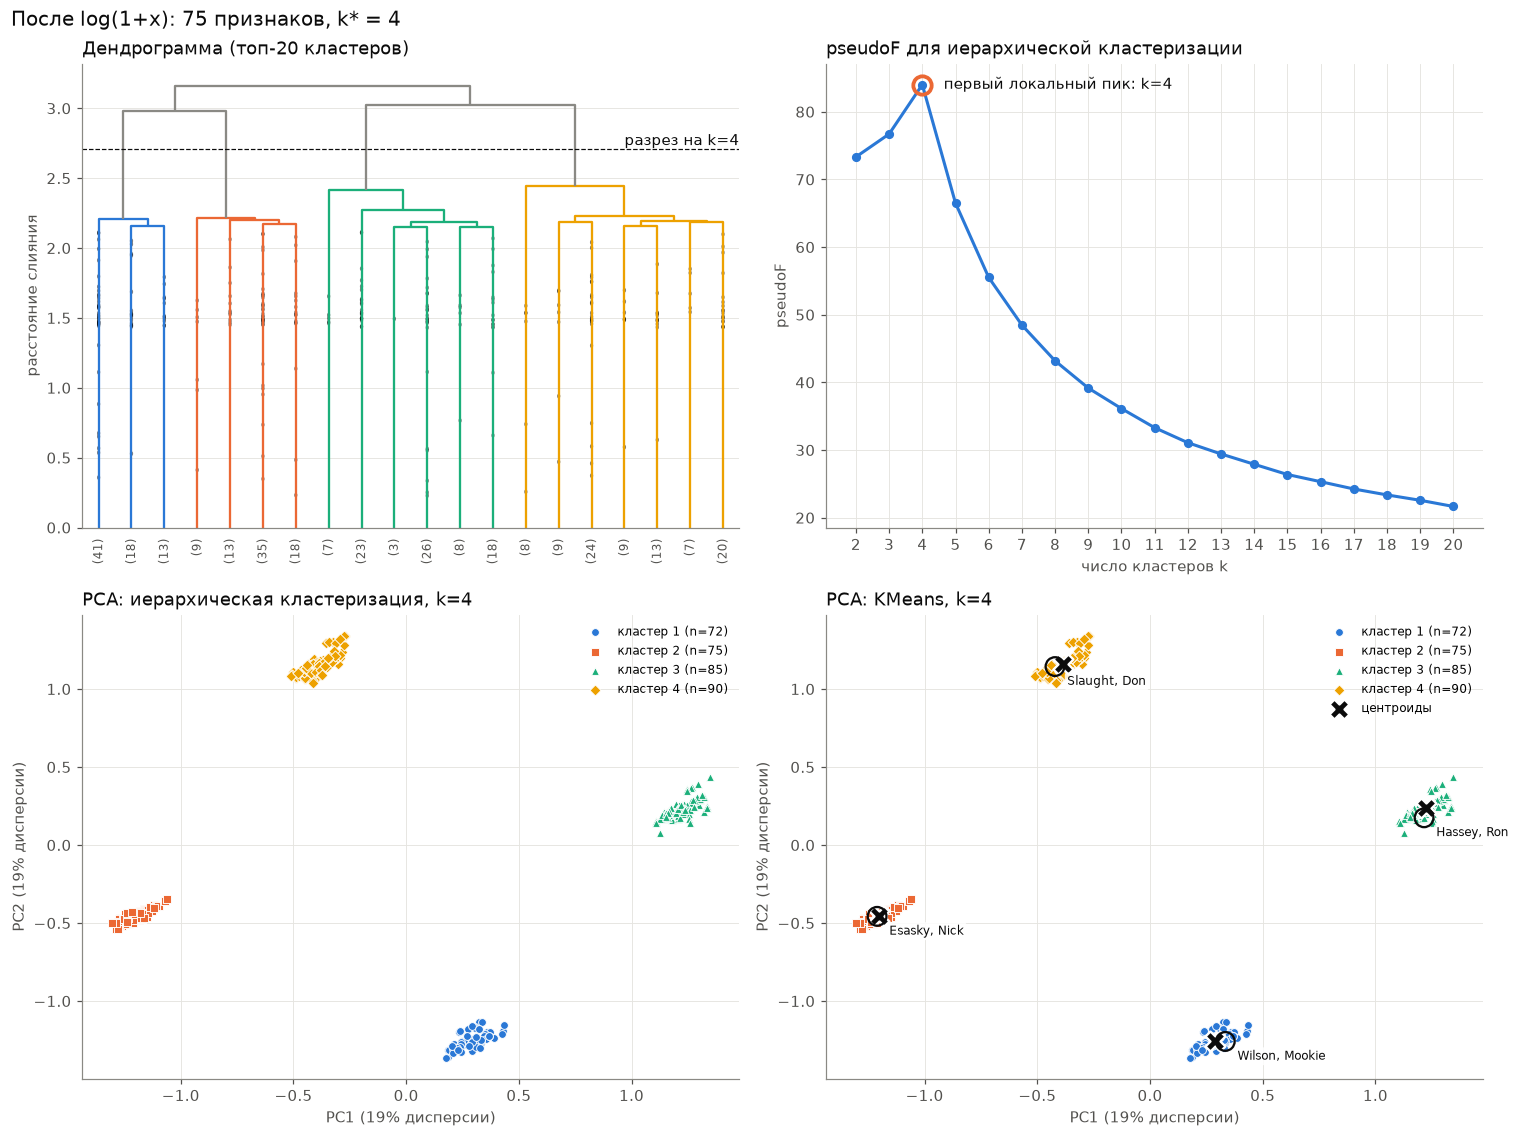

,игроков,типичный игрок,до центроида,YrMajor,nHits,nHome,nRuns,CrHits,nOuts,nAssts,Salary
кластер,,,,,,,,,,,
1,72,"Wilson, Mookie",1.341604,6.5,99.8,9.4,49.7,617.4,294.4,116.3,529.9
2,75,"Esasky, Nick",1.329960,8.1,96.8,9.5,46.4,818.8,298.1,111.2,475.1
3,85,"Hassey, Ron",1.349018,8.4,113.3,13.0,58.5,836.3,287.4,102.6,629.0
4,90,"Slaught, Don",1.351736,7.5,102.4,12.0,53.2,708.9,278.6,100.0,442.9


In [21]:
res_log = cluster_analysis(df_log, NUM, CAT, 'После log(1+x)', profile=df_imp)
res_log['typical']

In [22]:
print('Совпадение разбиений KMeans до и после логарифмирования:')
pd.crosstab(pd.Series(res_base['km_labels'], name='исходные'), pd.Series(res_log['km_labels'], name='log'))

Совпадение разбиений KMeans до и после логарифмирования:


log,1,2,3,4
исходные,,,,
1,0,75,0,0
2,72,0,0,0
3,0,0,85,0
4,0,0,0,90


In [23]:
# Вклад частей признакового пространства в квадрат расстояния между игроками
# (квадрат евклидова расстояния раскладывается в сумму по колонкам)
Xl = res_log['X']
num_sq, cat_sq = (pdist(Xl[NUM]) ** 2).mean(), (pdist(Xl.drop(columns=NUM)) ** 2).mean()
print(f'Средний квадрат расстояния: числовые {num_sq:.2f}, OneHot {cat_sq:.2f} '
      f'-> доля OneHot {cat_sq / (num_sq + cat_sq):.0%}')

Средний квадрат расстояния: числовые 1.24, OneHot 7.25 -> доля OneHot 85%


### Вывод по п.9

**Что изменилось.**
- **Число кластеров** не изменилось: k* = 4 (первый пик pseudoF; значение в пике 82.3 → 84.0).
- **Разбиение** то же самое: таблица сопряжённости диагональная, кластеры по-прежнему
  в точности совпадают с дивизионами AE / AW / NE / NW. **Проекция** PCA — те же четыре
  изолированных облака: PC1 и PC2 образованы колонками `Division_*` и `League_*`
  (веса ±0.54), числовые признаки в них почти не участвуют.
- **Типичные представители**: в NE и AE те же (Wilson, Mookie; Hassey, Ron), в NW
  Landreaux, Ken → Esasky, Nick, в AW Henderson, Dave → Slaught, Don. Внутри кластера
  расстояния теперь считаются по прологарифмированным показателям: хвосты сжаты, и
  ближайшим к центроиду оказывается другой игрок.

**Субъективное качество не изменилось**: кластеры описывают, в каком дивизионе играет
игрок, а не как он играет (средние показатели кластеров в таблицах почти одинаковы).

**Почему.** После `MaxAbsScaler` бинарные OneHot-колонки имеют ту же шкалу [0, 1], что и
числовые, но их 57 против 18, а дивизион закодирован трижды (League, Division, Div).
Игроки из разных дивизионов различаются минимум в 6 бинарных колонках (команда,
дивизион, лига или подлига) — это вклад ≥ 6 в квадрат расстояния, тогда как средний
вклад всех 18 числовых признаков ≈ 1.2. В итоге на OneHot-часть приходится ~85%
квадрата расстояния (расчёт выше). Логарифм меняет только числовую часть, поэтому на
разбиение почти не влияет. Сама симметризация полезна — хвосты `CrHome`, `CrBB` и др.
больше не растягивают шкалу, и при `MaxAbsScaler` основная масса игроков не прижата к
нулю, — но её эффект замаскирован категориальными признаками.

Побочный эффект: у `nOuts` асимметрия стала отрицательной (−2.2): 14 нулей (игроки,
не выходившие в защиту) после `log(1+x)` остались в нуле, далеко слева от остальных.

## 10. Отбор 5 переменных методом VarClus

VarClus — нисходящая кластеризация переменных: кластер переменных делится на два
по повёрнутым (varimax) главным компонентам, пока второе собственное значение
больше порога `maxeigval2` или не достигнуто `maxclus` кластеров. Из каждого
кластера берётся лучший представитель — переменная с минимальным
$RS\_Ratio = \dfrac{1-R^2_{own}}{1-R^2_{next\ closest}}$: она лучше всех объясняет
свой кластер и хуже всех — ближайший чужой.

VarClus работает с корреляциями числовых переменных (бинарные OneHot-колонки для
него не предназначены), поэтому на вход — 18 числовых переменных после п.9.

In [24]:
vc_default = VarClusHi(df_log[NUM], maxeigval2=1, maxclus=None)
vc_default.varclus()
print(f'С порогом из лекции (maxeigval2=1) VarClus останавливается на {len(vc_default.info)} кластерах:')
vc_default.info

С порогом из лекции (maxeigval2=1) VarClus останавливается на 3 кластерах:


,Cluster,N_Vars,Eigval1,Eigval2,VarProp
0,0,9,7.799007,0.672602,0.866556
1,1,6,4.628896,0.669818,0.771483
2,2,3,2.103784,0.674648,0.701261


С порогом 1 все вторые собственные значения уже меньше 1, и деление
останавливается на трёх кластерах. Чтобы получить 5 переменных по варианту,
снимаем порог (`maxeigval2=0`) и ограничиваем число кластеров `maxclus=5`.

In [25]:
vc = VarClusHi(df_log[NUM], maxeigval2=0, maxclus=5)
vc.varclus()
vc.info

,Cluster,N_Vars,Eigval1,Eigval2,VarProp
0,0,7,6.384155,0.290329,0.912022
1,1,6,4.628896,0.669818,0.771483
2,2,2,1.770103,0.229897,0.885052
3,3,1,1.000000,0.000000,1.000000
4,4,2,2.000000,0.000000,1.000000


In [26]:
rsq = vc.rsquare
best = rsq.loc[rsq.groupby('Cluster')['RS_Ratio'].idxmin()]
SELECTED = best['Variable'].tolist()
print('Отобранные переменные:', SELECTED)
rsq.style.apply(lambda r: ['font-weight: bold' if r['Variable'] in SELECTED else '' for _ in r], axis=1) \
   .format(precision=3)

Отобранные переменные: ['CrAtBat', 'nRuns', 'nAssts', 'nOuts', 'Salary']


,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
0,0,YrMajor,0.794,0.326,0.306
1,0,CrAtBat,0.973,0.654,0.078
2,0,CrHits,0.969,0.668,0.093
3,0,CrHome,0.788,0.520,0.442
4,0,CrRuns,0.966,0.672,0.102
5,0,CrRbi,0.972,0.664,0.083
6,0,CrBB,0.922,0.619,0.204
7,1,nAtBat,0.879,0.227,0.157
8,1,nHits,0.860,0.246,0.186
9,1,nHome,0.587,0.155,0.489


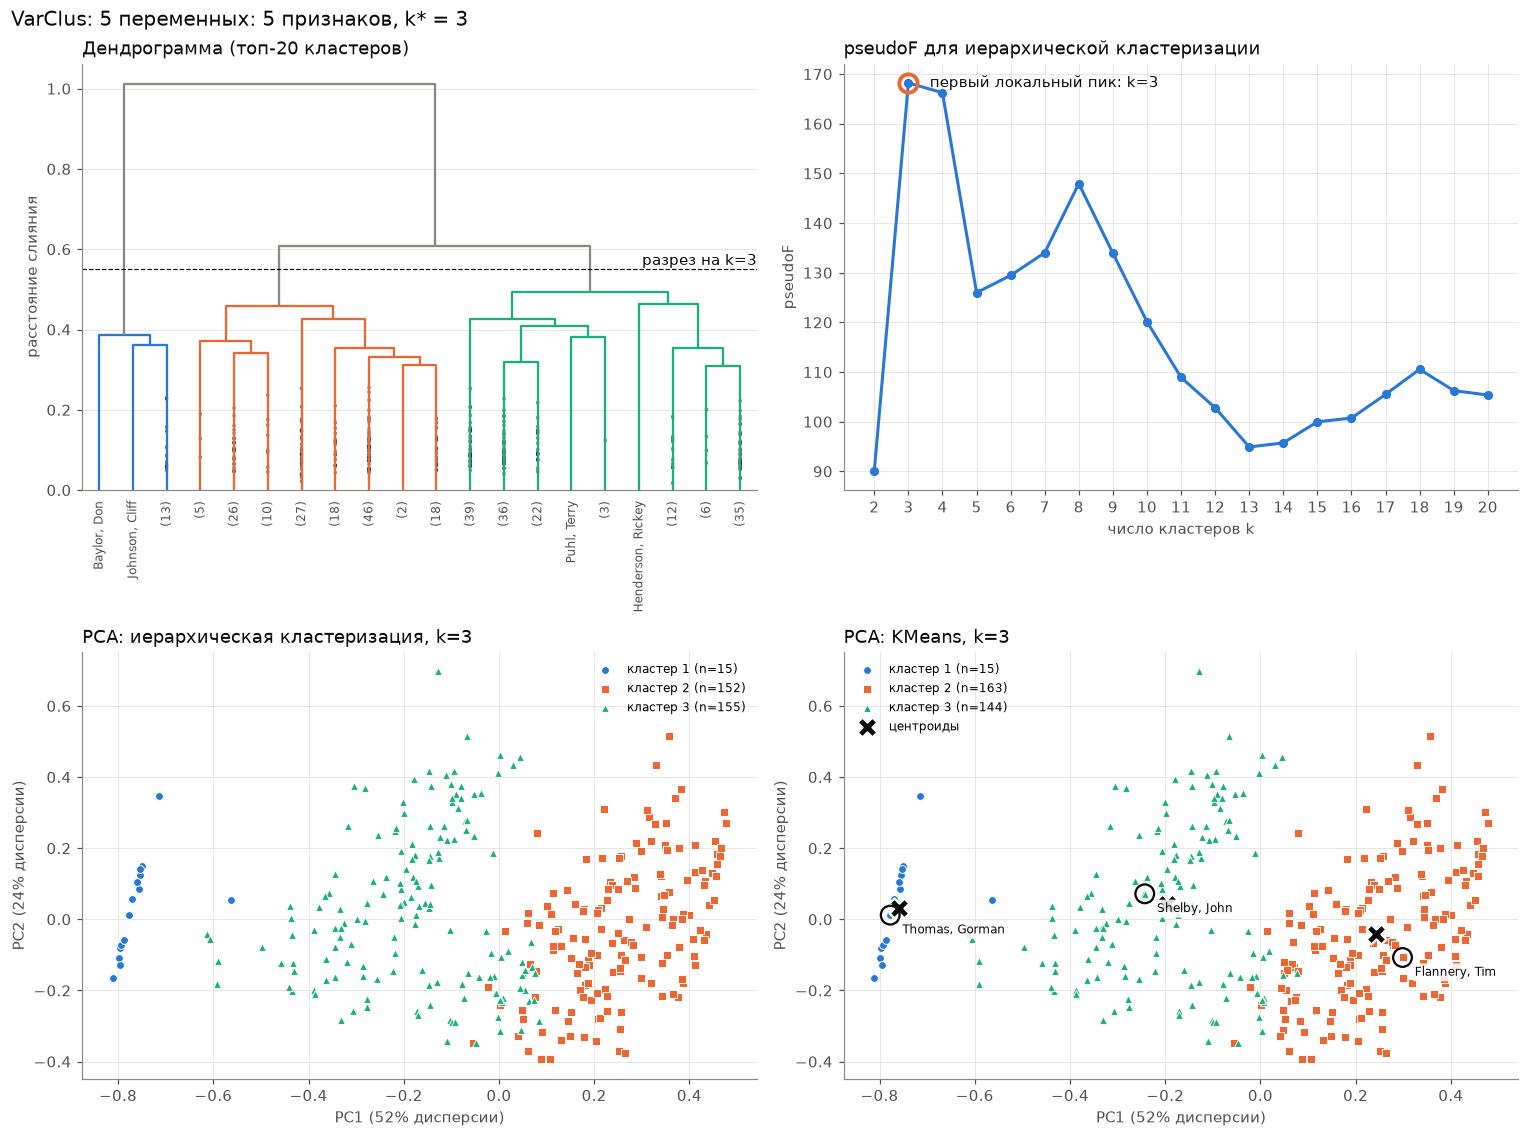

,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
pseudoF,90.1,168.2,166.2,126.0,129.5,134.0,147.9,133.9,120.1,108.9,102.8,94.9,95.7,100.0,100.7,105.5,110.5,106.3,105.4


,игроков,типичный игрок,до центроида,YrMajor,nHits,nHome,nRuns,CrHits,nOuts,nAssts,Salary
кластер,,,,,,,,,,,
1,15,"Thomas, Gorman",0.072924,13.0,96.9,17.1,50.9,1270.3,0.5,0.1,577.1
2,163,"Flannery, Tim",0.089542,8.0,109.2,10.4,53.2,793.6,360.5,201.9,567.5
3,144,"Shelby, John",0.062082,6.8,97.5,11.3,51.3,641.3,238.1,10.6,458.0


In [27]:
res_vc = cluster_analysis(df_log, SELECTED, [], 'VarClus: 5 переменных', profile=df_imp)
display(res_vc['pseudo_f'].round(1).to_frame('pseudoF').T)
res_vc['typical']

In [28]:
# Состав кластеров по позициям и лигам (позиции в отбор не входили)
top_pos = lambda r: ', '.join(f'{p} ({n})' for p, n in r[r > 0].sort_values(ascending=False).head(6).items())
pd.concat([pd.crosstab(res_vc['km_labels'], df_imp['Position']).apply(top_pos, axis=1).rename('частые позиции'),
           pd.crosstab(res_vc['km_labels'], df_imp['League'])], axis=1).rename_axis('кластер KMeans')

,частые позиции,American,National
кластер KMeans,,,
1,DH (15),15,0
2,"3B (32), 2B (31), SS (30), 1B (25), C (23), UT (9)",85,78
3,"OF (30), CF (26), RF (26), LF (25), C (17), 1B (6)",75,69


### Сравнение трёх прогонов

In [29]:
def summary(res):
    sizes = lambda l: ' / '.join(map(str, np.bincount(l)[1:]))
    return {'признаков': res['n_features'], 'k*': res['k'],
            'pseudoF(k*)': round(res['pseudo_f'][res['k']], 1),
            'размеры (иерархия)': sizes(res['hier_labels']),
            'размеры (KMeans)': sizes(res['km_labels']),
            'типичные игроки': ', '.join(res['typical']['типичный игрок'])}

pd.DataFrame({r['title']: summary(r) for r in [res_base, res_log, res_vc]}).T

,признаков,k*,pseudoF(k*),размеры (иерархия),размеры (KMeans),типичные игроки
Исходные данные,75,4,82.3,75 / 72 / 85 / 90,75 / 72 / 85 / 90,"Landreaux, Ken, Wilson, Mookie, Hassey, Ron, Henderson, Dave"
После log(1+x),75,4,84.0,72 / 75 / 85 / 90,72 / 75 / 85 / 90,"Wilson, Mookie, Esasky, Nick, Hassey, Ron, Slaught, Don"
VarClus: 5 переменных,5,3,168.2,15 / 152 / 155,15 / 163 / 144,"Thomas, Gorman, Flannery, Tim, Shelby, John"


In [30]:
# Связь кластеров с дивизионом (Div): в первых двух прогонах — один к одному
pd.concat({r['title']: pd.crosstab(r['km_labels'], df_imp['Div'])
           for r in [res_base, res_log, res_vc]}, names=['прогон', 'кластер KMeans'])

Div                                   AE  AW  NE  NW
прогон                кластер KMeans                
Исходные данные       1                0   0   0  75
                      2                0   0  72   0
                      3               85   0   0   0
                      4                0  90   0   0
После log(1+x)        1                0   0  72   0
                      2                0   0   0  75
                      3               85   0   0   0
                      4                0  90   0   0
VarClus: 5 переменных 1                7   8   0   0
                      2               42  43  38  40
                      3               36  39  34  35

### Вывод по п.10

**Отбор.** С порогом из лекции (`maxeigval2=1`) VarClus выделяет только 3 группы
переменных, поэтому деление продолжено до `maxclus=5`. Представители (минимальный
RS_Ratio):

| Группа переменных | Представитель |
|---|---|
| опыт и карьера: YrMajor + 6 карьерных `Cr*` | `CrAtBat` |
| игра в нападении за сезон: nAtBat, nHits, nHome, nRuns, nRBI, nBB | `nRuns` |
| игра в защите: nAssts, nError | `nAssts` |
| выносы: nOuts | `nOuts` |
| зарплата: Salary, logSalary (после п.9 — одинаковые столбцы) | `Salary` |

**Что изменилось.**
- **Число кластеров**: 4 → 3 (первый пик pseudoF при k = 3: 168.2; k = 4 почти так же
  хорош — 166.2, так что разбиения на 3 и 4 близки). Абсолютные значения pseudoF между
  прогонами не сравниваем — у них разное число признаков.
- **Кластеры** больше не связаны с дивизионом (таблица выше), зато совпадают с игровой
  ролью, хотя `Position` в отбор не входила:
  1. **Назначенные отбивающие, DH** (15 игроков): `nOuts` ≈ 0 и `nAssts` ≈ 0 — не играют
     в защите. Все 15 — позиция DH и все из Американской лиги (правило DH тогда
     действовало только в AL); в среднем 13 лет в лиге. Типичный — **Thomas, Gorman** (DH).
  2. **Инфилдеры** (163): 3B, 2B, SS, 1B, C; много передач (`nAssts` ≈ 202) и выносов.
     Типичный — **Flannery, Tim** (2B).
  3. **Аутфилдеры** (144): OF, CF, RF, LF; передач почти нет (`nAssts` ≈ 11).
     Типичный — **Shelby, John** (OF).
- **Проекция**: две главные компоненты объясняют 76% дисперсии (против 37% раньше).
  DH — отдельная компактная группа, а между инфилдом и аутфилдом непрерывный переход,
  который иерархия (152 / 155) и KMeans (163 / 144) режут немного по-разному.

**Субъективное качество заметно выросло**: кластеры интерпретируемы и описывают самих
игроков, а типичные представители — характерные игроки своей роли.

**Почему.**
1. Ушли 57 OneHot-колонок, которые давали ~85% расстояния и делили игроков по дивизионам.
2. VarClus убрал дублирование: раньше «опыт» входил в расстояние 7 раз (YrMajor и шесть
   карьерных переменных), «нападение» — 6 раз, «зарплата» — дважды; теперь каждый аспект
   представлен одной переменной, и вклад аспектов в расстояние выровнялся.
3. Представители разных групп слабо коррелированы, поэтому каждый добавляет новую
   информацию — в частности `nAssts` и `nOuts`, которые и разделяют позиции на поле.